# EHRSHOT data audit + small EDA

Цель ноутбука: быстро понять структуру EHRSHOT, проверить события, patient timelines, labels, splits, горизонты задач и понять, можно ли быстро запустить baseline.

## 0. Setup

EHRSHOT-MEDS явно разделяет:
- `data/**/*.parquet` — события пациента;
- `metadata/codes.parquet` — словарь кодов;
- `metadata/subject_splits.parquet` — train/tuning/held_out split;
- `labels/**/labels.parquet` — labels для задач.

In [1]:
from pathlib import Path
import json
import os
import glob

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

EHRSHOT_ROOT = Path("EHRSHOT_MEDS")

assert EHRSHOT_ROOT.exists(), f"Path does not exist: {EHRSHOT_ROOT}"
EHRSHOT_ROOT

PosixPath('EHRSHOT_MEDS')

## 1. Detect available files

In [5]:
data_file = EHRSHOT_ROOT / "data" / "data.parquet"
metadata_dir = EHRSHOT_ROOT / "metadata"
codes_path = metadata_dir / "codes.parquet"
splits_path = metadata_dir / "subject_splits.parquet"
dataset_json_path = metadata_dir / "dataset.json"
task_dir = EHRSHOT_ROOT / "labels"

print("data.parquet exists:", data_file.exists())
print("codes.parquet exists:", codes_path.exists())
print("subject_splits.parquet exists:", splits_path.exists())
print("dataset.json exists:", dataset_json_path.exists())
print("candidate task roots:", list(task_dir.glob("*"))[0:5])

data.parquet exists: True
codes.parquet exists: True
subject_splits.parquet exists: True
dataset.json exists: True
candidate task roots: [PosixPath('EHRSHOT_MEDS/labels/chexpert'), PosixPath('EHRSHOT_MEDS/labels/new_lupus'), PosixPath('EHRSHOT_MEDS/labels/new_hypertension'), PosixPath('EHRSHOT_MEDS/labels/lab_thrombocytopenia'), PosixPath('EHRSHOT_MEDS/labels/guo_icu')]


In [8]:
if dataset_json_path.exists():
    with open(dataset_json_path, "r") as f:
        dataset_meta = json.load(f)
    print(dataset_meta)
else:
    print("No metadata/dataset.json found")

{'dataset_name': 'EHRSHOT', 'dataset_version': '1.0', 'etl_name': 'EHRSHOT => MEDS ETL', 'etl_version': '1.0', 'meds_version': '0.3.3', 'created_at': '2024-10-08 21:59:33.393310'}


## 2. Load event table

В MEDS событие обычно задается как минимум тройкой `subject_id`, `time`, `code`, плюс optional значения: `numeric_value`, `text_value` и дополнительные колонки.

In [9]:
assert data_file.exists(), "No MEDS data parquet files found under data/**/*.parquet"

events_lf = pl.scan_parquet(str(data_file))
events_schema = events_lf.collect_schema()

print(events_schema)

Schema({'subject_id': Int64, 'time': Datetime(time_unit='us', time_zone=None), 'code': String, 'numeric_value': Float32, 'text_value': String, 'unit': String, 'omop_table': String})


In [10]:
global_event_stats = events_lf.select([
    pl.len().alias("n_events"),
    pl.col("subject_id").n_unique().alias("n_subjects"),
    pl.col("code").n_unique().alias("n_unique_codes"),
    pl.col("time").is_null().mean().alias("time_null_rate"),
]).collect()

global_event_stats

n_events,n_subjects,n_unique_codes,time_null_rate
u32,u32,u32,f64
41661637,6739,31252,0.0


Основная таблица событий имеет следующую схему:

```text
subject_id: Int64
time: Datetime
code: String
numeric_value: Float32
text_value: String
unit: String
omop_table: String
```

Эта схема хорошо подходит для longitudinal EHR modeling. Каждое событие описывается через:

* `subject_id` — идентификатор пациента;
* `time` — время события;
* `code` — медицинский или служебный код события;
* `numeric_value` — числовое значение, например для лабораторных измерений или vital signs;
* `text_value` — текстовое значение, если оно есть;
* `unit` — единица измерения;
* `omop_table` — источник события в OMOP-структуре.

Общие размеры event table:

```text
n_events = 41,661,637
n_subjects = 6,739
n_unique_codes = 31,252
time_null_rate = 0.0
```

Это важный результат: все события имеют timestamp, то есть временная структура не потеряна. Для нашего проекта это критично, потому что fixed-horizon risk prediction требует четко отделять историю до index time от будущих событий после index time.

Вывод: EHRSHOT-MEDS содержит крупную продольную event table: 41.7 млн событий для 6,739 пациентов. Наличие timestamps у всех событий позволяет строить patient timelines, делать временные фильтры, рассчитывать признаки до `prediction_time` и контролировать leakage.

## 3. Splits

Проверяем, есть ли готовые subject-level splits. В MEDS обычно используются `train`, `tuning`, `held_out`; в оригинальном EHRSHOT могут использоваться train/val/test labels.

In [11]:
if splits_path.exists():
    splits = pl.read_parquet(splits_path)
    display(splits.head().to_pandas())
    display(splits.group_by("split").agg(pl.len().alias("n_subjects")).to_pandas())
else:
    splits = None
    print("No subject_splits.parquet found")

,subject_id,split
0,115971637,tuning
1,115970526,tuning
2,115968232,tuning
3,115969919,tuning
4,115968793,tuning


,split,n_subjects
0,held_out,2212
1,tuning,2232
2,train,2295


В датасете есть готовое subject-level разбиение:

```text
held_out: 2,212 patients
tuning:   2,232 patients
train:    2,295 patients
```

В MEDS-терминах:

* `train` — обучение;
* `tuning` — валидация / подбор гиперпараметров;
* `held_out` — финальная тестовая выборка.

Важно, что split задан на уровне пациента, а не на уровне отдельных label rows. Это снижает риск утечки информации между train и test через одного и того же пациента. Для медицинских данных это принципиально: если события одного пациента попадут одновременно в train и test, модель может фактически запоминать историю пациента, а не обобщать риск.

Вывод: готовые splits есть, поэтому для baseline не нужно делать случайное разбиение вручную. В дальнейших экспериментах следует использовать именно `train/tuning/held_out`, чтобы сохранить совместимость с benchmark-логикой EHRSHOT и не получить завышенные метрики из-за patient-level leakage.

## 4. Event families and code dictionary

In [36]:
code_family_expr = pl.col("code").str.split("/").list.get(0).fill_null("UNKNOWN").alias("code_family")

code_family_counts = (
    events_lf
    .with_columns(code_family_expr)
    .group_by("code_family")
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
        pl.col("code").n_unique().alias("n_codes"),
    ])
    .sort("n_events", descending=True)
    .collect()
)

display(code_family_counts.to_pandas().head(30))

,code_family,n_events,n_subjects,n_codes
0,LOINC,32095577,6739,3946
1,SNOMED,4769737,6739,11598
2,RxNorm,2349784,5837,5433
3,CPT4,1162788,6636,4675
4,Visit,380317,6191,6
5,Domain,316295,6510,1
6,CARE_SITE,199469,5741,386
7,Medicare Specialty,178767,6338,1
8,RxNorm Extension,99961,4437,422
9,CMS Place of Service,47714,3505,2


In [37]:
top_codes = (
    events_lf
    .group_by("code")
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
    ])
    .sort("n_events", descending=True)
    .head(50)
    .collect()
)

display(top_codes.to_pandas())

,code,n_events,n_subjects
0,LOINC/8867-4,2615625,5942
1,LOINC/8480-6,1945652,5955
2,LOINC/8462-4,1645872,5955
3,LOINC/3151-8,1481794,5788
4,LOINC/8478-0,1290047,5744
5,LOINC/9279-1,1238803,5665
6,LOINC/LP21258-6,1131300,5790
7,LOINC/8310-5,1117121,6014
8,LOINC/20112-9,891101,2485
9,LOINC/60804-2,791176,2798


In [38]:
if codes_path.exists():
    codes = pl.read_parquet(codes_path)
    print(codes.schema)
    display(codes.head(20).to_pandas())
else:
    codes = None
    print("No codes.parquet found")

Schema({'code': String, 'description': String, 'parent_codes': List(String)})


,code,description,parent_codes
0,SNOMED/3950001,,None
1,Race/5,,None
2,Gender/F,,None
3,Ethnicity/Not Hispanic,,None
4,LOINC/68848-1,,None
5,LOINC/11506-3,,None
6,LOINC/2714-4,,None
7,LOINC/19218-7,,None
8,LOINC/3150-0,,None
9,LOINC/8310-5,,None


После группировки кодов по префиксу до `/` были получены нормальные code families. Самые крупные семейства событий:

```text
LOINC:              32,095,577 events, 6,739 subjects, 3,946 codes
SNOMED:              4,769,737 events, 6,739 subjects, 11,598 codes
RxNorm:              2,349,784 events, 5,837 subjects, 5,433 codes
CPT4:                1,162,788 events, 6,636 subjects, 4,675 codes
Visit:                 380,317 events, 6,191 subjects, 6 codes
Domain:                316,295 events, 6,510 subjects, 1 code
CARE_SITE:             199,469 events, 5,741 subjects, 386 codes
Medicare Specialty:    178,767 events, 6,338 subjects, 1 code
```

Большая доля `LOINC` показывает, что в датасете очень много лабораторных измерений, vital signs или других observation-like событий. Это важно для нашего проекта, потому что missing-aware блок для лабораторных данных действительно имеет смысл: лабораторные события не только многочисленны, но и представлены через числовые значения.

`SNOMED` и `RxNorm` также важны: `SNOMED` отражает клинические понятия и диагнозы/состояния, а `RxNorm` — лекарства. `CPT4` связан с процедурами. Наличие `Visit` позволяет восстанавливать наблюдаемую историю контактов пациента с медицинской системой.

Топ конкретных кодов также в основном представлены LOINC-кодами. Например:

```text
LOINC/8867-4
LOINC/8480-6
LOINC/8462-4
LOINC/3151-8
LOINC/8478-0
LOINC/9279-1
```

Многие из них встречаются у нескольких тысяч пациентов и имеют миллионы событий. Это подтверждает, что EHRSHOT содержит плотные временные ряды по repeated measurements.

Словарь кодов `codes.parquet` имеет схему:

```text
code: String
description: String
parent_codes: List(String)
```

Однако в первых строках `description` часто пустой. Поэтому для интерпретации отдельных кодов может потребоваться дополнительное сопоставление с внешними словарями LOINC/SNOMED/RxNorm или документацией EHRSHOT.

Вывод: структура событий богата и клинически разнообразна. В датасете есть лабораторные события, диагнозы/состояния, лекарства, процедуры, визиты и статические patient-level признаки. Для первого baseline можно начать с count-based признаков по code families и top codes, а для следующих этапов — отдельно обработать лабораторные numeric events, диагнозы и repeated chronic-condition codes.

## 5. Patient timeline statistics

Смотрим длину истории пациента, число уникальных кодов и длительность наблюдения. Это важно для long-context аргумента и для будущей compression идеи.

In [15]:
per_subject = (
    events_lf
    .group_by("subject_id")
    .agg([
        pl.len().alias("n_events"),
        pl.col("code").n_unique().alias("n_unique_codes"),
        pl.col("time").drop_nulls().min().alias("first_time"),
        pl.col("time").drop_nulls().max().alias("last_time"),
    ])
    .with_columns([
        (pl.col("last_time") - pl.col("first_time")).dt.total_days().alias("followup_days")
    ])
    .collect()
)

display(per_subject.describe().to_pandas())
display(per_subject.head().to_pandas())

,statistic,subject_id,n_events,n_unique_codes,first_time,last_time,followup_days
0,count,6.739000e+03,6739.000000,6739.000000,6739,6739,6739.000000
1,null_count,0.000000e+00,0.000000,0.000000,0,0,0.000000
2,mean,1.159758e+08,6182.169016,395.077905,1960-01-13 00:22:00.552011,2019-04-30 04:23:56.545481,21656.270812
3,std,1.660643e+05,10406.319346,315.693474,None,None,6555.537553
4,min,1.159671e+08,10.000000,6.000000,1909-09-03 00:00:00,1998-05-23 23:59:00,7002.000000
5,25%,1.159688e+08,682.000000,174.000000,1946-02-18 00:00:00,2016-03-11 23:59:00,16268.000000
6,50%,1.159705e+08,2592.000000,315.000000,1957-11-21 00:00:00,2022-01-27 14:10:00,22545.000000
7,75%,1.159721e+08,7375.000000,522.000000,1975-01-23 00:00:00,2022-12-28 23:59:00,26930.000000
8,max,1.211250e+08,199913.000000,2643.000000,2003-10-24 00:00:00,2023-03-09 08:00:00,32506.000000


,subject_id,n_events,n_unique_codes,first_time,last_time,followup_days
0,115967756,6747,455,1954-08-10,2023-02-06 23:59:00,25017
1,115973398,381,135,1951-04-24,2014-02-20 16:02:00,22948
2,115971525,885,160,1963-05-31,2008-03-29 23:59:00,16374
3,115968524,58,22,1915-08-18,1999-01-29 23:59:00,30480
4,115968506,710,132,1962-02-02,2022-07-31 23:59:00,22094


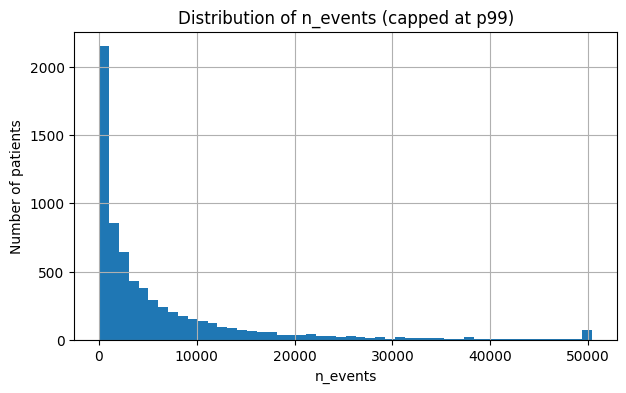

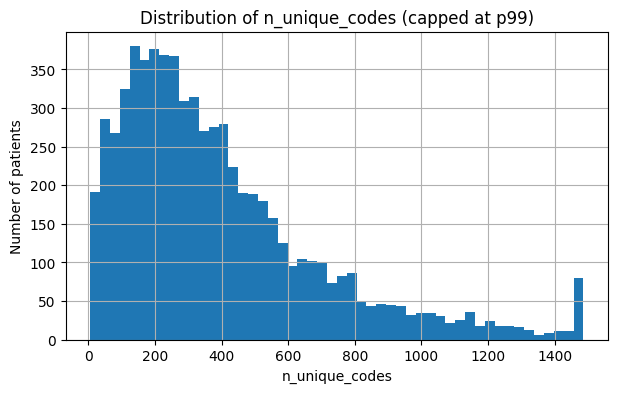

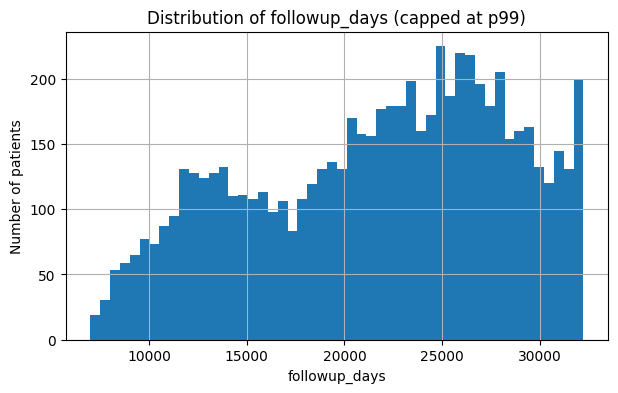

In [16]:
pdf = per_subject.select(["n_events", "n_unique_codes", "followup_days"]).to_pandas()

for col in ["n_events", "n_unique_codes", "followup_days"]:
    plt.figure(figsize=(7, 4))
    values = pdf[col].dropna()
    # cap extreme tail for readable EDA
    cap = values.quantile(0.99)
    values.clip(upper=cap).hist(bins=50)
    plt.title(f"Distribution of {col} (capped at p99)")
    plt.xlabel(col)
    plt.ylabel("Number of patients")
    plt.show()

In [47]:
# 1. Проверяем, какие события стоят на самой ранней дате пациента

first_times = (
    events_lf
    .group_by("subject_id")
    .agg(pl.col("time").min().alias("first_time"))
)

earliest_events = (
    events_lf
    .join(first_times, on="subject_id", how="inner")
    .filter(pl.col("time") == pl.col("first_time"))
    .with_columns(
        pl.col("code")
        .str.split("/")
        .list.get(0)
        .fill_null("UNKNOWN")
        .alias("code_family")
    )
)

earliest_code_families = (
    earliest_events
    .group_by(["code_family", "omop_table"])
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
        pl.col("code").n_unique().alias("n_codes"),
    ])
    .sort("n_events", descending=True)
    .collect()
)

display(earliest_code_families.to_pandas().head(50))

,code_family,omop_table,n_events,n_subjects,n_codes
0,SNOMED,person,6739,6739,1


In [48]:
# 2. Смотрим конкретные самые частые earliest codes

earliest_top_codes = (
    earliest_events
    .group_by(["code", "omop_table"])
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
    ])
    .sort("n_events", descending=True)
    .collect()
)

display(earliest_top_codes.to_pandas().head(50))

,code,omop_table,n_events,n_subjects
0,SNOMED/3950001,person,6739,6739


In [49]:
# 3. Считаем span от первого Visit/* события

visit_events_lf = events_lf.filter(
    pl.col("code").str.starts_with("Visit/")
)

visit_per_subject = (
    visit_events_lf
    .group_by("subject_id")
    .agg([
        pl.len().alias("n_visit_events"),
        pl.col("time").min().alias("first_visit_time"),
        pl.col("time").max().alias("last_visit_time"),
    ])
    .with_columns([
        (
            pl.col("last_visit_time") - pl.col("first_visit_time")
        ).dt.total_days().alias("visit_span_days")
    ])
    .collect()
)

display(visit_per_subject.describe().to_pandas())
display(visit_per_subject.head().to_pandas())

,statistic,subject_id,n_visit_events,first_visit_time,last_visit_time,visit_span_days
0,count,6.191000e+03,6191.000000,6191,6191,6191.000000
1,null_count,0.000000e+00,0.000000,0,0,0.000000
2,mean,1.159763e+08,61.430625,2013-11-11 15:03:38.921014,2018-11-07 13:41:10.709093,1821.496043
3,std,1.732502e+05,97.647980,None,None,1744.477870
4,min,1.159671e+08,1.000000,2000-06-29 23:59:00,2001-05-08 23:59:00,0.000000
5,25%,1.159688e+08,8.000000,2009-09-26 19:00:00,2015-10-04 02:14:00,294.000000
6,50%,1.159705e+08,25.000000,2013-10-15 09:07:00,2020-07-05 23:59:00,1258.000000
7,75%,1.159722e+08,70.000000,2017-11-04 15:20:00,2022-09-17 09:00:00,2989.000000
8,max,1.211250e+08,1146.000000,2023-02-02 17:47:00,2023-03-08 10:53:00,8242.000000


,subject_id,n_visit_events,first_visit_time,last_visit_time,visit_span_days
0,115971936,5,2014-04-09 16:45:00,2022-10-02 15:04:00,3097
1,115971653,5,2020-09-25 11:10:00,2020-09-30 23:59:00,5
2,115968000,26,2019-10-01 19:08:00,2020-05-15 23:59:00,227
3,115968932,42,2006-01-20 01:02:00,2019-02-02 08:39:00,4761
4,115969831,40,2015-01-23 18:11:00,2019-11-25 11:40:00,1766


In [50]:
# 4. Clinical events after first observed visit

static_prefixes = [
    "Gender/",
    "Race/",
    "Ethnicity/",
]

non_static_condition = pl.lit(True)

for prefix in static_prefixes:
    non_static_condition = non_static_condition & ~pl.col("code").str.starts_with(prefix)

first_visit_lf = (
    visit_events_lf
    .group_by("subject_id")
    .agg(pl.col("time").min().alias("first_visit_time"))
)

clinical_after_first_visit_lf = (
    events_lf
    .join(first_visit_lf, on="subject_id", how="inner")
    .filter(non_static_condition)
    .filter(pl.col("time") >= pl.col("first_visit_time"))
)

clinical_after_first_visit_per_subject = (
    clinical_after_first_visit_lf
    .group_by("subject_id")
    .agg([
        pl.len().alias("n_clinical_events_after_first_visit"),
        pl.col("code").n_unique().alias("n_unique_clinical_codes_after_first_visit"),
        pl.col("time").min().alias("first_event_after_first_visit"),
        pl.col("time").max().alias("last_event_after_first_visit"),
        pl.col("first_visit_time").min().alias("first_visit_time"),
    ])
    .with_columns([
        (
            pl.col("last_event_after_first_visit") - pl.col("first_visit_time")
        ).dt.total_days().alias("clinical_span_after_first_visit_days")
    ])
    .collect()
)

display(clinical_after_first_visit_per_subject.describe().to_pandas())
display(clinical_after_first_visit_per_subject.head().to_pandas())

,statistic,subject_id,n_clinical_events_after_first_visit,n_unique_clinical_codes_after_first_visit,first_event_after_first_visit,last_event_after_first_visit,first_visit_time,clinical_span_after_first_visit_days
0,count,6.191000e+03,6191.000000,6191.000000,6191,6191,6191,6191.000000
1,null_count,0.000000e+00,0.000000,0.000000,0,0,0,0.000000
2,mean,1.159763e+08,6514.919884,408.498950,2013-11-11 15:03:38.921014,2020-05-02 14:41:37.854950,2013-11-11 15:03:38.921014,2363.584720
3,std,1.732502e+05,10629.585681,315.853346,None,None,None,1750.356504
4,min,1.159671e+08,2.000000,2.000000,2000-06-29 23:59:00,2001-08-23 23:59:00,2000-06-29 23:59:00,0.000000
5,25%,1.159688e+08,818.000000,192.000000,2009-09-26 19:00:00,2018-01-31 23:59:00,2009-09-26 19:00:00,855.000000
6,50%,1.159705e+08,2893.000000,331.000000,2013-10-15 09:07:00,2022-03-21 23:59:00,2013-10-15 09:07:00,2140.000000
7,75%,1.159722e+08,7845.000000,537.000000,2017-11-04 15:20:00,2023-01-03 23:59:00,2017-11-04 15:20:00,3640.000000
8,max,1.211250e+08,199851.000000,2634.000000,2023-02-02 17:47:00,2023-03-09 08:00:00,2023-02-02 17:47:00,8246.000000


,subject_id,n_clinical_events_after_first_visit,n_unique_clinical_codes_after_first_visit,first_event_after_first_visit,last_event_after_first_visit,first_visit_time,clinical_span_after_first_visit_days
0,115968920,875,209,2009-01-15 06:00:00,2009-04-09 13:59:00,2009-01-15 06:00:00,84
1,115971400,9191,641,2007-09-20 23:59:00,2022-10-20 23:59:00,2007-09-20 23:59:00,5509
2,115971171,15114,632,2014-01-11 11:50:00,2022-10-22 23:59:00,2014-01-11 11:50:00,3206
3,115972174,1536,326,2018-03-12 08:30:00,2021-08-25 23:59:00,2018-03-12 08:30:00,1262
4,115967720,3128,342,2008-12-10 15:37:00,2015-10-29 23:59:00,2008-12-10 15:37:00,2514


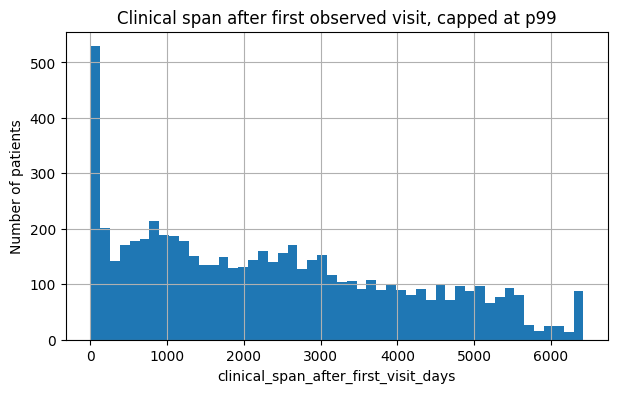

In [51]:
pdf = clinical_after_first_visit_per_subject.to_pandas()

plt.figure(figsize=(7, 4))
pdf["clinical_span_after_first_visit_days"].dropna().clip(
    upper=pdf["clinical_span_after_first_visit_days"].dropna().quantile(0.99)
).hist(bins=50)

plt.title("Clinical span after first observed visit, capped at p99")
plt.xlabel("clinical_span_after_first_visit_days")
plt.ylabel("Number of patients")
plt.show()

In [52]:
eda_summary = pd.DataFrame([
    {
        "metric": "Total patients",
        "value": 6739,
    },
    {
        "metric": "Patients with Visit/* events",
        "value": 6191,
    },
    {
        "metric": "Patients without Visit/* events",
        "value": 6739 - 6191,
    },
    {
        "metric": "Median visit events per patient",
        "value": 25,
    },
    {
        "metric": "Median visit-based span, days",
        "value": 1258,
    },
    {
        "metric": "Median visit-based span, years",
        "value": round(1258 / 365.25, 2),
    },
    {
        "metric": "Median clinical events after first visit",
        "value": 2893,
    },
    {
        "metric": "Median unique clinical codes after first visit",
        "value": 331,
    },
    {
        "metric": "Median clinical span after first visit, days",
        "value": 2140,
    },
    {
        "metric": "Median clinical span after first visit, years",
        "value": round(2140 / 365.25, 2),
    },
])

display(eda_summary)

,metric,value
0,Total patients,6739.00
1,Patients with Visit/* events,6191.00
2,Patients without Visit/* events,548.00
3,Median visit events per patient,25.00
4,"Median visit-based span, days",1258.00
5,"Median visit-based span, years",3.44
6,Median clinical events after first visit,2893.00
7,Median unique clinical codes after first visit,331.00
8,"Median clinical span after first visit, days",2140.00
9,"Median clinical span after first visit, years",5.86


Первичная статистика по полным patient timelines показала:

```text
n_subjects = 6,739
median n_events = 2,592
mean n_events = 6,182
max n_events = 199,913

median n_unique_codes = 315
mean n_unique_codes = 395
max n_unique_codes = 2,643

median raw followup_days = 22,545
mean raw followup_days = 21,656
```

На первый взгляд raw follow-up выглядит очень большим: медиана около 22,545 дней, то есть более 60 лет. Но этот показатель нельзя напрямую интерпретировать как реальное клиническое наблюдение. Дополнительная проверка показала, что самое раннее событие у каждого пациента одинаковое:

```text
code_family = SNOMED
omop_table = person
code = SNOMED/3950001
n_subjects = 6,739
```

То есть raw timeline начинается с person-level события, вероятно связанного с patient/person table, а не с первым реальным медицинским визитом. Поэтому raw `first_time` завышает длительность наблюдения.

Более корректная оценка была сделана через `Visit/*` события. Для visit-based span:

```text
patients with Visit/* events = 6,191 из 6,739
patients without Visit/* events = 548

median n_visit_events = 25
mean n_visit_events = 61.4
max n_visit_events = 1,146

median visit_span_days = 1,258 дней ≈ 3.4 года
mean visit_span_days = 1,821 дней ≈ 5.0 лет
p75 visit_span_days = 2,989 дней ≈ 8.2 года
max visit_span_days = 8,242 дней ≈ 22.6 года
```

После этого был рассчитан clinical span после первого наблюдаемого визита. Для всех событий после первого `Visit/*`:

```text
patients = 6,191
median n_clinical_events_after_first_visit = 2,893
mean n_clinical_events_after_first_visit = 6,515
max n_clinical_events_after_first_visit = 199,851

median n_unique_clinical_codes_after_first_visit = 331
mean n_unique_clinical_codes_after_first_visit = 408
max n_unique_clinical_codes_after_first_visit = 2,634

median clinical_span_after_first_visit_days = 2,140 дней ≈ 5.9 лет
mean clinical_span_after_first_visit_days = 2,364 дней ≈ 6.5 лет
p75 clinical_span_after_first_visit_days = 3,640 дней ≈ 10.0 лет
max = 8,246 дней ≈ 22.6 года
```

Вывод: raw first-to-last span нельзя использовать как клинический follow-up, потому что начало timeline связано с person-level записью. Более честная оценка через первый визит показывает, что EHRSHOT действительно содержит длинные и плотные longitudinal histories: медианный пациент имеет около 2,900 клинических событий после первого визита, 331 уникальный код и почти 6 лет наблюдаемой клинической истории. Это хорошо поддерживает идею long-context modeling и persistence-aware compression, потому что истории длинные, неоднородные и потенциально содержат много повторяющихся событий.

## 6. Numeric values / labs audit

Для missing-aware идеи важно понять, какие события имеют `numeric_value`, насколько они плотные, и какие коды чаще всего представлены как числовые измерения.

In [39]:
cols = events_schema.names()

if "numeric_value" in cols:
    numeric_stats = events_lf.select([
        pl.col("numeric_value").is_not_null().sum().alias("n_numeric_events"),
        pl.col("numeric_value").is_not_null().mean().alias("numeric_event_rate"),
    ]).collect()
    display(numeric_stats)

    top_numeric_codes = (
        events_lf
        .filter(pl.col("numeric_value").is_not_null())
        .group_by("code")
        .agg([
            pl.len().alias("n_numeric_events"),
            pl.col("subject_id").n_unique().alias("n_subjects"),
            pl.col("numeric_value").mean().alias("mean_value"),
            pl.col("numeric_value").std().alias("std_value"),
        ])
        .sort("n_numeric_events", descending=True)
        .head(50)
        .collect()
    )
    display(top_numeric_codes.to_pandas())
else:
    print("No numeric_value column found")

n_numeric_events,numeric_event_rate
u32,f64
29048497,0.697248


,code,n_numeric_events,n_subjects,mean_value,std_value
0,LOINC/8867-4,2615625,5942,80.451035,70.004837
1,LOINC/8480-6,1945652,5955,118.599922,23.518089
2,LOINC/8462-4,1645872,5955,67.208267,14.826961
3,LOINC/3151-8,1481794,5788,8.227993,24.344578
4,LOINC/8478-0,1290047,5744,84.431107,16.336498
5,LOINC/9279-1,1238802,5665,17.616800,6.476579
6,LOINC/LP21258-6,1131300,5790,96.326080,4.294370
7,LOINC/8310-5,1116860,5989,78.954590,28.302132
8,LOINC/20112-9,891101,2485,444.967407,142.817215
9,LOINC/60804-2,791176,2798,0.807295,0.531205


В event table есть числовые значения `numeric_value`. Общая статистика:

```text
n_numeric_events = 29,048,497
numeric_event_rate = 0.697248
```

То есть около 69.7% всех событий имеют числовое значение. Это очень высокая доля, и она показывает, что EHRSHOT-MEDS содержит большое количество измеряемых клинических событий: лабораторные показатели, vital signs или другие observation-like записи.

Топ numeric codes в основном представлены LOINC-кодами. Например:

```text
LOINC/8867-4      2,615,625 numeric events, 5,942 subjects
LOINC/8480-6      1,945,652 numeric events, 5,955 subjects
LOINC/8462-4      1,645,872 numeric events, 5,955 subjects
LOINC/3151-8      1,481,794 numeric events, 5,788 subjects
LOINC/8478-0      1,290,047 numeric events, 5,744 subjects
LOINC/9279-1      1,238,803 numeric events, 5,665 subjects
```

Такая структура важна для нашего проекта по двум причинам.

Во-первых, лабораторные и числовые признаки можно использовать в baseline: например, брать последнее значение до `prediction_time`, mean/min/max за последние 30/90/365 дней, количество измерений, trend и time-since-last-measurement.

Во-вторых, этот блок подтверждает применимость missing-aware идеи. В EHR данные факт измерения сам по себе может быть информативным: если анализ часто назначается, это может отражать тяжесть состояния, наблюдение за осложнением или подозрение врача. Поэтому в будущем baseline стоит добавлять не только сами значения лабораторных показателей, но и:

```text
measurement indicator
measurement frequency
time since last measurement
number of measurements in recent windows
missingness mask
```

Вывод: numeric events занимают большую часть EHRSHOT event table. Это делает датасет подходящим для экспериментов с лабораторными траекториями и missing-aware признаками. Для первого MVP можно начать с простых агрегатов по top LOINC-кодам, а затем добавить missingness-aware representation.

## 7. Discover task labels

Labels обычно лежат отдельно от raw events. Ищем parquet-файлы с колонками `subject_id`, `prediction_time`, и одной label-колонкой: `boolean_value`, `integer_value`, `float_value`, `categorical_value`.

In [40]:
label_files = list((EHRSHOT_ROOT / "labels").glob("**/*.parquet"))
print("n label parquet files:", len(label_files))
for p in label_files[:30]:
    print(p.relative_to(EHRSHOT_ROOT))

n label parquet files: 15
labels/chexpert/labels.parquet
labels/new_lupus/labels.parquet
labels/new_hypertension/labels.parquet
labels/lab_thrombocytopenia/labels.parquet
labels/guo_icu/labels.parquet
labels/lab_hypoglycemia/labels.parquet
labels/new_hyperlipidemia/labels.parquet
labels/guo_los/labels.parquet
labels/guo_readmission/labels.parquet
labels/lab_hyponatremia/labels.parquet
labels/lab_hyperkalemia/labels.parquet
labels/new_celiac/labels.parquet
labels/new_pancan/labels.parquet
labels/lab_anemia/labels.parquet
labels/new_acutemi/labels.parquet


In [41]:
def infer_task_name(path: Path, root: Path):
    # Prefer task/label/benchmark as task root
    parts = path.relative_to(root).parts
    for marker in ["tasks", "labels", "benchmark"]:
        if marker in parts:
            i = parts.index(marker)
            # exclude filename; keep nested task name
            return "/".join(parts[i+1:-1]) or path.stem
    return path.parent.name

task_to_files = {}
for p in label_files:
    task = infer_task_name(p, EHRSHOT_ROOT)
    task_to_files.setdefault(task, []).append(p)

print("n tasks discovered:", len(task_to_files))
for task, files in list(task_to_files.items())[:50]:
    print(task, "->", len(files), "files")

n tasks discovered: 15
chexpert -> 1 files
new_lupus -> 1 files
new_hypertension -> 1 files
lab_thrombocytopenia -> 1 files
guo_icu -> 1 files
lab_hypoglycemia -> 1 files
new_hyperlipidemia -> 1 files
guo_los -> 1 files
guo_readmission -> 1 files
lab_hyponatremia -> 1 files
lab_hyperkalemia -> 1 files
new_celiac -> 1 files
new_pancan -> 1 files
lab_anemia -> 1 files
new_acutemi -> 1 files


In [42]:
LABEL_COLS = [
    "boolean_value",
    "integer_value",
    "float_value",
    "categorical_value",
    "label",
    "value",
]

def detect_non_null_label_col(lf: pl.LazyFrame, candidate_cols: list[str]):
    schema_cols = lf.collect_schema().names()
    existing = [c for c in candidate_cols if c in schema_cols]

    if not existing:
        return None, pd.DataFrame()

    null_stats = (
        lf.select([
            pl.col(c).is_not_null().sum().alias(c)
            for c in existing
        ])
        .collect()
        .to_pandas()
        .T
        .reset_index()
    )

    null_stats.columns = ["column", "n_non_null"]

    non_null = null_stats[null_stats["n_non_null"] > 0]

    if non_null.empty:
        return existing[0], null_stats

    return non_null.iloc[0]["column"], null_stats


def summarize_task_fixed(task, files, splits=None):
    lf = pl.scan_parquet([str(p) for p in files])
    schema = lf.collect_schema().names()

    label_col, label_col_stats = detect_non_null_label_col(lf, LABEL_COLS)

    if label_col is None:
        return {
            "task": task,
            "error": f"No known label column found. Schema={schema}",
        }, None, None

    base = (
        lf.select([
            pl.len().alias("n_labels"),
            pl.col("subject_id").n_unique().alias("n_subjects"),
            (
                pl.col("prediction_time").min().alias("min_prediction_time")
                if "prediction_time" in schema
                else pl.lit(None).alias("min_prediction_time")
            ),
            (
                pl.col("prediction_time").max().alias("max_prediction_time")
                if "prediction_time" in schema
                else pl.lit(None).alias("max_prediction_time")
            ),
        ])
        .collect()
        .to_dicts()[0]
    )

    base["task"] = task
    base["label_col"] = label_col

    value_counts = (
        lf.group_by(label_col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .collect()
        .to_pandas()
    )

    split_counts = None

    if splits is not None and "subject_id" in schema:
        split_counts = (
            lf.join(splits.lazy(), on="subject_id", how="left")
            .group_by(["split", label_col])
            .agg([
                pl.len().alias("n_labels"),
                pl.col("subject_id").n_unique().alias("n_subjects"),
            ])
            .sort(["split", label_col])
            .collect()
            .to_pandas()
        )

    return base, value_counts, split_counts

In [43]:
fixed_task_summaries = []
fixed_task_tables = {}

for task, files in task_to_files.items():
    base, value_counts, split_counts = summarize_task_fixed(
        task,
        files,
        splits=splits,
    )

    fixed_task_summaries.append(base)

    fixed_task_tables[task] = {
        "value_counts": value_counts,
        "split_counts": split_counts,
    }

fixed_summary_df = pd.DataFrame(fixed_task_summaries)
display(fixed_summary_df)

for task, tables in fixed_task_tables.items():
    print("\n" + "=" * 100)
    print(task)
    print("- value counts")
    display(tables["value_counts"])

    if tables["split_counts"] is not None:
        print("- split counts")
        display(tables["split_counts"])

,n_labels,n_subjects,min_prediction_time,max_prediction_time,task,label_col
0,26275,1045,1998-04-21 21:35:00,2023-03-06 16:39:00,chexpert,integer_value
1,7038,3864,2007-12-09 23:59:00,2023-02-25 23:59:00,new_lupus,boolean_value
2,3764,2328,2007-12-21 23:59:00,2023-02-15 23:59:00,new_hypertension,boolean_value
3,179618,6063,1998-02-22 03:19:00,2023-03-08 11:02:00,lab_thrombocytopenia,integer_value
4,6491,3617,2007-11-04 23:59:00,2023-02-21 23:59:00,guo_icu,boolean_value
5,318164,5974,1998-12-05 18:44:00,2023-03-08 11:02:00,lab_hypoglycemia,integer_value
6,4442,2650,2007-12-09 23:59:00,2023-02-22 23:59:00,new_hyperlipidemia,boolean_value
7,6995,3855,2007-11-04 23:59:00,2023-02-21 23:59:00,guo_los,boolean_value
8,7003,3718,2007-12-09 23:59:00,2023-01-30 23:59:00,guo_readmission,boolean_value
9,212837,5921,1998-05-29 08:24:00,2023-03-08 11:02:00,lab_hyponatremia,integer_value



chexpert
- value counts


,integer_value,n
0,8192,9072
1,0,2869
2,8193,1987
3,1024,1707
4,512,1070
...,...,...
543,2596,1
544,1673,1
545,1176,1
546,1283,1


- split counts


,split,integer_value,n_labels,n_subjects
0,held_out,0,1076,260
1,held_out,1,217,112
2,held_out,2,116,54
3,held_out,3,57,26
4,held_out,4,37,29
...,...,...,...,...
1012,tuning,6657,1,1
1013,tuning,6913,1,1
1014,tuning,6976,1,1
1015,tuning,8192,3334,334


...

,split,integer_value,n_labels,n_subjects
0,held_out,0,18185,1754
1,held_out,1,7636,1151
2,held_out,2,31180,1167
3,held_out,3,1154,275
4,train,0,21473,1883
5,train,1,9544,1251
6,train,2,37902,1246
7,train,3,1582,329
8,tuning,0,17726,1738
9,tuning,1,7445,1122



new_acutemi
- value counts


,boolean_value,n
0,False,6373
1,True,464


- split counts


,split,boolean_value,n_labels,n_subjects
0,held_out,False,1983,1149
1,held_out,True,144,115
2,train,False,2359,1264
3,train,True,175,130
4,tuning,False,2031,1150
5,tuning,True,145,112


В датасете было найдено 15 task-specific label-файлов:

```text
chexpert
new_lupus
new_hypertension
lab_thrombocytopenia
guo_icu
lab_hypoglycemia
new_hyperlipidemia
guo_los
guo_readmission
lab_hyponatremia
lab_hyperkalemia
new_celiac
new_pancan
lab_anemia
new_acutemi
```

Каждая задача хранится в отдельном `labels.parquet`. Это удобно, потому что raw events и target labels разделены. Такая структура снижает риск случайно смешать будущие target events с входными признаками.

Задачи используют разные типы label-полей:

```text
chexpert                  integer_value
new_lupus                 boolean_value
new_hypertension          boolean_value
lab_thrombocytopenia      integer_value
guo_icu                   boolean_value
lab_hypoglycemia          integer_value
new_hyperlipidemia        boolean_value
guo_los                   boolean_value
guo_readmission           boolean_value
lab_hyponatremia          integer_value
lab_hyperkalemia          integer_value
new_celiac                boolean_value
new_pancan                boolean_value
lab_anemia                integer_value
new_acutemi               boolean_value
```

Размеры задач:

```text
chexpert:                 26,275 labels, 1,045 subjects
new_lupus:                 7,038 labels, 3,864 subjects
new_hypertension:          3,764 labels, 2,328 subjects
lab_thrombocytopenia:    179,618 labels, 6,063 subjects
guo_icu:                  6,491 labels, 3,617 subjects
lab_hypoglycemia:        318,164 labels, 5,974 subjects
new_hyperlipidemia:        4,442 labels, 2,650 subjects
guo_los:                  6,995 labels, 3,855 subjects
guo_readmission:          7,003 labels, 3,718 subjects
lab_hyponatremia:        212,837 labels, 5,921 subjects
lab_hyperkalemia:        200,170 labels, 5,931 subjects
new_celiac:               7,129 labels, 3,899 subjects
new_pancan:               7,011 labels, 3,864 subjects
lab_anemia:             184,880 labels, 6,086 subjects
new_acutemi:              6,837 labels, 3,834 subjects
```

Наиболее релевантные задачи для нашего проекта:

### `guo_readmission`

```text
n_labels = 7,003
n_subjects = 3,718
False = 6,092
True = 911
positive rate ≈ 13.0%
```

Это лучший кандидат для первого MVP, потому что задача напрямую соответствует 30-day readmission risk. Она достаточно крупная, имеет понятный clinical outcome и умеренный class imbalance.

### `guo_los`

```text
n_labels = 6,995
n_subjects = 3,855
False = 5,228
True = 1,767
positive rate ≈ 25.3%
```

Эта задача подходит как стабильный operational outcome. Она менее дисбалансная, чем ICU transfer и rare diagnosis tasks, поэтому может быть удобной для отладки baseline pipeline.

### `guo_icu`

```text
n_labels = 6,491
n_subjects = 3,617
False = 6,201
True = 290
positive rate ≈ 4.5%
```

Эта задача клинически важна, но сильно дисбалансная. Для нее особенно важны AUPRC, calibration и аккуратная работа с threshold.

### New diagnosis tasks

К задачам first diagnosis относятся:

```text
new_hypertension
new_hyperlipidemia
new_lupus
new_celiac
new_pancan
new_acutemi
```

Эти задачи полезны для 365-day risk setting, потому что они связаны с появлением нового диагноза после index time. Однако некоторые из них имеют редкие positive labels, например `new_celiac` и `new_lupus`, поэтому для первого baseline они менее удобны.

### Lab tasks

К лабораторным задачам относятся:

```text
lab_thrombocytopenia
lab_hypoglycemia
lab_hyponatremia
lab_hyperkalemia
lab_anemia
```

Они имеют очень много label rows, но это не fixed 30/90/365-day patient-level risk в прямом смысле. Скорее это задачи предсказания следующего лабораторного состояния/категории. Они полезны для missing-aware экспериментов, но не должны быть первым target для patient-level risk profiling.

Вывод: для первого baseline лучше взять `guo_readmission`, потому что она ближе всего к задаче 30-day risk prediction. Второй кандидат — `guo_los`, потому что задача более сбалансированная и удобна для проверки pipeline. `guo_icu` можно использовать позже как более сложный clinical deterioration/resource-use target. Для 365-day горизонта можно рассмотреть `new_*` diagnosis tasks. Нативной 90-day задачи среди стандартных labels не видно, поэтому 90-day prediction нужно либо отложить, либо формировать самостоятельно из событий.

## 8. Prediction-time leakage check

Для каждой задачи нужно убедиться, что признаки для baseline считаются только из событий `time <= prediction_time`.
Первичный sanity check: у label samples должны быть события до prediction_time, иначе sample нельзя нормально использовать.

In [31]:
def leakage_sanity_check_for_task(
    task_keyword: str,
    max_labels: int = 2000,
    task_to_label_file: dict | None = None,
    events_lf: pl.LazyFrame = events_lf,
):
    """
    Проверяет, есть ли у label rows события пациента ДО prediction_time.

    Это sanity check для будущего baseline:
    - n_events_before_prediction показывает, сколько событий можно легально использовать как признаки;
    - n_events_after_prediction показывает, сколько событий лежит в будущем и НЕ должно попасть в признаки.
    """

    if task_to_label_file is None:
        label_files = sorted(task_dir.glob("*/labels.parquet"))
        task_to_label_file = {p.parent.name: p for p in label_files}

    matches = {
        task_name: path
        for task_name, path in task_to_label_file.items()
        if task_keyword.lower() in task_name.lower()
    }

    if not matches:
        print("No task matched keyword:", task_keyword)
        print("Available tasks:")
        for task_name in sorted(task_to_label_file.keys()):
            print("-", task_name)
        raise ValueError(f"No task matched keyword: {task_keyword}")

    task_name, label_path = sorted(matches.items())[0]

    print("Selected task:", task_name)
    print("Label file:", label_path)

    labels_lf = pl.scan_parquet(str(label_path))
    label_schema = labels_lf.collect_schema().names()

    required_cols = {"subject_id", "prediction_time"}
    missing_cols = required_cols - set(label_schema)

    if missing_cols:
        raise ValueError(
            f"Task {task_name} does not have required columns {missing_cols}. "
            f"Schema: {label_schema}"
        )

    possible_label_cols = [
        "boolean_value",
        "integer_value",
        "float_value",
        "categorical_value",
        "label",
        "value",
    ]

    label_cols = [c for c in possible_label_cols if c in label_schema]

    selected_cols = ["subject_id", "prediction_time"] + label_cols

    labels = (
        labels_lf
        .select(selected_cols)
        .filter(pl.col("prediction_time").is_not_null())
        .head(max_labels)
        .collect()
    )

    if labels.height == 0:
        raise ValueError(f"No non-null prediction_time rows found for task {task_name}")

    subject_ids = labels["subject_id"].unique().to_list()

    event_times = (
        events_lf
        .filter(pl.col("subject_id").is_in(subject_ids))
        .select(["subject_id", "time"])
        .filter(pl.col("time").is_not_null())
        .collect()
    )

    labels_pd = labels.to_pandas()
    events_pd = event_times.to_pandas()

    labels_pd["prediction_time"] = pd.to_datetime(labels_pd["prediction_time"])
    events_pd["time"] = pd.to_datetime(events_pd["time"])

    events_by_subject = {
        subject_id: group["time"].sort_values().to_numpy(dtype="datetime64[ns]")
        for subject_id, group in events_pd.groupby("subject_id")
    }

    n_events_before = []
    n_events_after = []
    last_event_before = []
    first_event_after = []

    for _, row in labels_pd.iterrows():
        subject_id = row["subject_id"]
        prediction_time = np.datetime64(row["prediction_time"], "ns")

        times = events_by_subject.get(
            subject_id,
            np.array([], dtype="datetime64[ns]")
        )

        split_idx = np.searchsorted(times, prediction_time, side="right")

        before_count = int(split_idx)
        after_count = int(len(times) - split_idx)

        n_events_before.append(before_count)
        n_events_after.append(after_count)

        if before_count > 0:
            last_event_before.append(pd.Timestamp(times[before_count - 1]))
        else:
            last_event_before.append(pd.NaT)

        if after_count > 0:
            first_event_after.append(pd.Timestamp(times[split_idx]))
        else:
            first_event_after.append(pd.NaT)

    checked = labels_pd.copy()
    checked["n_events_before_prediction"] = n_events_before
    checked["n_events_after_prediction"] = n_events_after
    checked["last_event_before_prediction"] = last_event_before
    checked["first_event_after_prediction"] = first_event_after

    checked["has_history_before_prediction"] = (
        checked["n_events_before_prediction"] > 0
    )

    checked["has_future_events_after_prediction"] = (
        checked["n_events_after_prediction"] > 0
    )

    checked["days_since_last_event"] = (
        checked["prediction_time"] - checked["last_event_before_prediction"]
    ).dt.total_seconds() / 86400

    summary = pd.DataFrame([
        {
            "task": task_name,
            "n_checked_labels": len(checked),
            "n_unique_subjects": checked["subject_id"].nunique(),
            "share_with_history_before_prediction": checked["has_history_before_prediction"].mean(),
            "share_with_future_events_after_prediction": checked["has_future_events_after_prediction"].mean(),
            "median_events_before_prediction": checked["n_events_before_prediction"].median(),
            "median_events_after_prediction": checked["n_events_after_prediction"].median(),
            "median_days_since_last_event": checked["days_since_last_event"].median(),
        }
    ])

    return checked, summary

In [32]:
# Пример: 30-day readmission
# Если task называется не readmission, функция выведет список доступных задач.

readmission_checked, readmission_leakage_summary = leakage_sanity_check_for_task(
    task_keyword="readmission",
    max_labels=2000,
)

display(readmission_leakage_summary)
display(readmission_checked.head(10))

Selected task: guo_readmission
Label file: EHRSHOT_MEDS/labels/guo_readmission/labels.parquet


,task,n_checked_labels,n_unique_subjects,share_with_history_before_prediction,share_with_future_events_after_prediction,median_events_before_prediction,median_events_after_prediction,median_days_since_last_event
0,guo_readmission,2000,997,1.0,1.0,5084.0,4326.5,0.0


,subject_id,prediction_time,boolean_value,integer_value,float_value,categorical_value,n_events_before_prediction,n_events_after_prediction,last_event_before_prediction,first_event_after_prediction,has_history_before_prediction,has_future_events_after_prediction,days_since_last_event
0,115972658,2009-08-29 23:59:00,False,NaN,NaN,None,303,43,2009-08-29 23:59:00,2009-09-02 14:29:00,True,True,0.000000
1,121124987,2014-06-18 23:59:00,False,NaN,NaN,None,2952,1623,2014-06-18 23:59:00,2014-06-24 09:55:00,True,True,0.000000
2,115972175,2010-02-06 23:59:00,False,NaN,NaN,None,1342,1648,2010-02-06 23:59:00,2010-02-08 14:47:00,True,True,0.000000
3,115972225,2010-05-18 23:59:00,False,NaN,NaN,None,835,28,2010-05-18 23:59:00,2010-05-19 23:59:00,True,True,0.000000
4,115973258,2022-07-23 23:59:00,False,NaN,NaN,None,6368,531,2022-07-23 23:59:00,2022-07-26 14:54:00,True,True,0.000000
5,115972682,2008-11-30 23:59:00,False,NaN,NaN,None,1836,564,2008-11-30 16:15:00,2008-12-01 11:20:00,True,True,0.322222
6,115973293,2017-10-28 23:59:00,False,NaN,NaN,None,3289,2713,2017-10-28 23:59:00,2017-10-29 15:02:00,True,True,0.000000
7,115973293,2018-10-14 23:59:00,False,NaN,NaN,None,5829,173,2018-10-14 23:59:00,2018-10-15 16:54:00,True,True,0.000000
8,115972192,2009-04-10 23:59:00,False,NaN,NaN,None,733,19131,2009-04-10 23:59:00,2009-04-12 21:11:00,True,True,0.000000
9,115972192,2017-06-03 23:59:00,False,NaN,NaN,None,11749,8115,2017-06-03 23:59:00,2017-06-05 23:59:00,True,True,0.000000


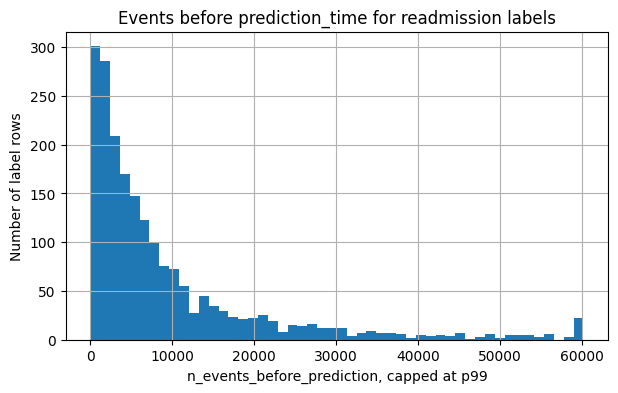

In [33]:
plt.figure(figsize=(7, 4))
readmission_checked["n_events_before_prediction"].clip(
    upper=readmission_checked["n_events_before_prediction"].quantile(0.99)
).hist(bins=50)

plt.title("Events before prediction_time for readmission labels")
plt.xlabel("n_events_before_prediction, capped at p99")
plt.ylabel("Number of label rows")
plt.show()

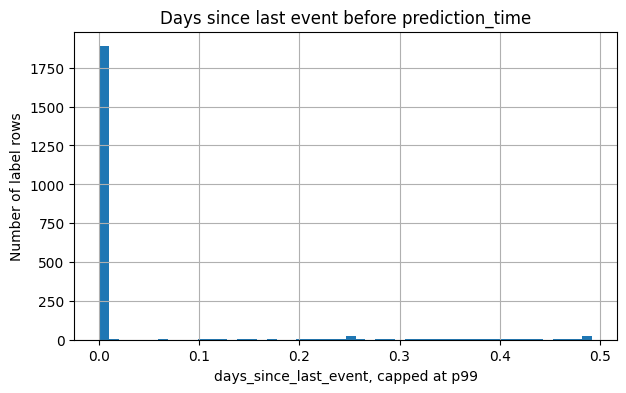

In [34]:
plt.figure(figsize=(7, 4))
readmission_checked["days_since_last_event"].dropna().clip(
    upper=readmission_checked["days_since_last_event"].dropna().quantile(0.99)
).hist(bins=50)

plt.title("Days since last event before prediction_time")
plt.xlabel("days_since_last_event, capped at p99")
plt.ylabel("Number of label rows")
plt.show()

In [35]:
# Можно проверить другую задачу, например ICU transfer

icu_checked, icu_leakage_summary = leakage_sanity_check_for_task(
    task_keyword="icu",
    max_labels=2000,
)

display(icu_leakage_summary)
display(icu_checked.head(10))

Selected task: guo_icu
Label file: EHRSHOT_MEDS/labels/guo_icu/labels.parquet


,task,n_checked_labels,n_unique_subjects,share_with_history_before_prediction,share_with_future_events_after_prediction,median_events_before_prediction,median_events_after_prediction,median_days_since_last_event
0,guo_icu,2000,1051,1.0,1.0,3493.0,5649.0,0.0


,subject_id,prediction_time,boolean_value,integer_value,float_value,categorical_value,n_events_before_prediction,n_events_after_prediction,last_event_before_prediction,first_event_after_prediction,has_history_before_prediction,has_future_events_after_prediction,days_since_last_event
0,115973157,2022-12-09 23:59:00,False,NaN,NaN,None,5181,2815,2022-12-09 23:59:00,2022-12-10 00:50:00,True,True,0.0
1,115973052,2017-01-08 23:59:00,False,NaN,NaN,None,811,36975,2017-01-08 23:59:00,2017-01-09 00:01:00,True,True,0.0
2,115973052,2017-02-11 23:59:00,True,NaN,NaN,None,2260,35526,2017-02-11 23:59:00,2017-02-12 00:01:00,True,True,0.0
3,115973052,2017-04-09 23:59:00,False,NaN,NaN,None,16137,21649,2017-04-09 23:59:00,2017-04-10 03:00:00,True,True,0.0
4,115973052,2017-04-21 23:59:00,False,NaN,NaN,None,17682,20104,2017-04-21 23:59:00,2017-04-22 01:00:00,True,True,0.0
5,115973052,2017-05-19 23:59:00,False,NaN,NaN,None,20308,17478,2017-05-19 23:59:00,2017-05-20 00:03:00,True,True,0.0
6,115973052,2017-06-08 23:59:00,False,NaN,NaN,None,21114,16672,2017-06-08 23:59:00,2017-06-09 02:21:00,True,True,0.0
7,115973052,2017-12-15 23:59:00,False,NaN,NaN,None,23908,13878,2017-12-15 23:59:00,2017-12-16 05:58:00,True,True,0.0
8,115973052,2018-02-04 23:59:00,False,NaN,NaN,None,25255,12531,2018-02-04 23:59:00,2018-02-05 03:29:00,True,True,0.0
9,115973052,2018-03-19 23:59:00,False,NaN,NaN,None,27304,10482,2018-03-19 23:59:00,2018-03-20 04:13:00,True,True,0.0


Для задач `guo_readmission` и `guo_icu` был выполнен sanity check на prediction-time leakage. Логика проверки: для каждой label row нужно убедиться, что у пациента есть события до `prediction_time`, и отдельно оценить, сколько событий лежит после `prediction_time`.

Это важно, потому что baseline должен строить признаки только из событий:

```text
event.time <= prediction_time
```

Если использовать события после `prediction_time`, модель увидит будущее: повторную госпитализацию, ICU transfer, новые диагнозы или связанные с ними лабораторные изменения. В таком случае метрики будут завышены и не будут отражать реальное качество предсказания.

Для `guo_readmission` на 2,000 label rows:

```text
n_checked_labels = 2,000
n_unique_subjects = 997
share_with_history_before_prediction = 1.0
share_with_future_events_after_prediction = 1.0
median_events_before_prediction = 5,084
median_events_after_prediction = 4,326.5
median_days_since_last_event = 0.0
```

Интерпретация:

* у всех проверенных label rows есть история до `prediction_time`, значит baseline можно строить;
* у всех проверенных label rows есть события после `prediction_time`, значит риск leakage реальный;
* медианное число событий до prediction time равно 5,084, что подтверждает наличие длинной истории пациента;
* `median_days_since_last_event = 0.0`, значит часто последнее доступное событие находится в день prediction time. Для admission/discharge-based задач это ожидаемо, но при feature engineering нужно явно решить, используем ли `<= prediction_time` или строго `< prediction_time`.

Для `guo_icu` на 2,000 label rows:

```text
n_checked_labels = 2,000
n_unique_subjects = 1,051
share_with_history_before_prediction = 1.0
share_with_future_events_after_prediction = 1.0
median_events_before_prediction = 3,493
median_events_after_prediction = 5,649
median_days_since_last_event = 0.0
```

Интерпретация аналогичная: история до index time есть, но будущих событий тоже много. Поэтому фильтр по времени является обязательным.

Вывод: prediction-time leakage check подтверждает, что EHRSHOT подходит для baseline-моделирования: у label rows есть достаточная история до prediction time. Но одновременно проверка показывает, что почти у всех samples есть будущие события, поэтому leakage control должен быть центральной частью preprocessing. Любой baseline должен строить признаки только из прошлого относительно `prediction_time`.

## 9. Minimal audit conclusions

Заполните эту ячейку после запуска notebook: какие файлы есть, где events, где labels, какие splits, какие задачи подходят под 30/90/365, и какой baseline проще всего запускать.

In [30]:
audit = {
    "n_data_files": 1,
    "n_events": int(global_event_stats["n_events"][0]),
    "n_subjects": int(global_event_stats["n_subjects"][0]),
    "n_unique_codes": int(global_event_stats["n_unique_codes"][0]),
    "split_counts": splits.group_by("split").agg(pl.len().alias("n_subjects")).to_pandas().to_dict("records") if splits is not None else None,
    "n_discovered_tasks": len(task_to_files),
    "task_names": list(task_to_files.keys()),
}

audit

{'n_data_files': 1,
 'n_events': 41661637,
 'n_subjects': 6739,
 'n_unique_codes': 31252,
 'split_counts': [{'split': 'train', 'n_subjects': 2295},
  {'split': 'held_out', 'n_subjects': 2212},
  {'split': 'tuning', 'n_subjects': 2232}],
 'n_discovered_tasks': 15,
 'task_names': ['chexpert',
  'new_lupus',
  'new_hypertension',
  'lab_thrombocytopenia',
  'guo_icu',
  'lab_hypoglycemia',
  'new_hyperlipidemia',
  'guo_los',
  'guo_readmission',
  'lab_hyponatremia',
  'lab_hyperkalemia',
  'new_celiac',
  'new_pancan',
  'lab_anemia',
  'new_acutemi']}

### Какие файлы есть?

В EHRSHOT-MEDS есть основная event table, metadata, code dictionary, subject-level splits и 15 task-specific label files. Структура достаточна для воспроизводимого baseline pipeline.

### Как устроена история пациента?

История пациента устроена как продольная последовательность событий:

```text
subject_id, time, code, numeric_value, text_value, unit, omop_table
```

Каждый пациент имеет ordered timeline. События включают лабораторные измерения, диагнозы/состояния, лекарства, процедуры, визиты и статические patient-level признаки.

### Где события?

События лежат в:

```text
EHRSHOT_MEDS/data/data.parquet
```

### Где признаки?

Готовые model features в этом MEDS-аудите отдельно не использовались. Признаки нужно формировать из event table. Для baseline можно сделать:

* counts по кодам до `prediction_time`;
* counts по code families;
* последние значения top numeric LOINC-кодов;
* агрегаты лабораторных значений;
* visit counts;
* time-since-last-event;
* time-since-last-measurement;
* missingness indicators.

### Где target labels?

Target labels лежат в:

```text
EHRSHOT_MEDS/labels/<task_name>/labels.parquet
```

Каждый label-файл содержит `subject_id`, `prediction_time` и label value. Для binary задач это обычно `boolean_value`, для lab и chexpert задач — `integer_value`.

### Какие задачи есть?

Всего найдено 15 задач. Они делятся на несколько групп:

* operational outcomes: `guo_readmission`, `guo_los`, `guo_icu`;
* new diagnosis tasks: `new_hypertension`, `new_hyperlipidemia`, `new_lupus`, `new_celiac`, `new_pancan`, `new_acutemi`;
* lab anticipation tasks: `lab_thrombocytopenia`, `lab_hypoglycemia`, `lab_hyponatremia`, `lab_hyperkalemia`, `lab_anemia`;
* imaging/report task: `chexpert`.

### Есть ли готовые train/val/test split?

Да. Есть готовый patient-level split:

```text
train
tuning
held_out
```

Для baseline следует использовать именно его.

### Какие горизонты используются?

Для нашего проекта наиболее важны:

* `guo_readmission` — 30-day readmission risk;
* `new_*` diagnosis tasks — подходят как приближение к 365-day risk;
* `guo_los` и `guo_icu` — operational/resource-use outcomes;
* lab tasks — не 30/90/365 patient-level risk, но полезны для missing-aware modeling.

Нативной 90-day задачи в найденных labels нет. Для 90-day risk prediction потребуется отдельная label construction логика или другой датасет.

### Можно ли быстро запустить baseline?

Да. Быстрый baseline можно запускать. Наиболее реалистичный первый baseline:

```text
target: guo_readmission
features: count-based codes + visit counts + simple numeric aggregates before prediction_time
model: Logistic Regression / CatBoost / XGBoost
splits: train / tuning / held_out
metrics: AUROC, AUPRC, Brier score, calibration
```

Для начала лучше не брать lab tasks как основной target, потому что они отличаются по постановке. Их лучше использовать позже для missing-aware блока.

# Финальный вывод

По итогам EHRSHOT data audit можно сделать вывод, что EHRSHOT-MEDS подходит для первого MVP по patient-level risk profiling, особенно для задачи 30-day readmission.

Датасет успешно загружен и имеет корректную MEDS-структуру. Основная таблица содержит 41.7 млн timestamped events для 6,739 пациентов и 31,252 уникальных кодов. Все события имеют время, что позволяет строить leakage-safe признаки относительно `prediction_time`.

Структура событий клинически богатая: основную часть составляют LOINC-события, также присутствуют SNOMED, RxNorm, CPT4, Visit и другие code families. Около 69.7% событий имеют `numeric_value`, что делает датасет подходящим для анализа лабораторных и измеряемых показателей. Это подтверждает применимость missing-aware подхода, где важно учитывать не только значения анализов, но и факт их наличия/отсутствия, частоту измерений и время с последнего измерения.

Первичная raw timeline статистика показала очень длинные first-to-last spans, но дополнительная проверка выявила, что самое раннее событие у каждого пациента — это person-level код `SNOMED/3950001`. Поэтому raw follow-up нельзя интерпретировать как реальную длительность клинического наблюдения. Более корректная оценка через первый `Visit/*` показала, что у 6,191 пациента есть visit events, медианный visit-based span составляет 1,258 дней, а медианный clinical span после первого визита — 2,140 дней. При этом медианный пациент имеет 2,893 клинических события после первого визита и 331 уникальный клинический код. Это подтверждает, что EHRSHOT содержит длинные и плотные longitudinal histories, где действительно имеет смысл исследовать long-context modeling и compression повторяющихся событий.

В датасете найдено 15 prediction tasks. Для нашего проекта наиболее релевантны `guo_readmission`, `guo_los`, `guo_icu` и `new_*` diagnosis tasks. Лучший первый target — `guo_readmission`, потому что он соответствует 30-day readmission risk, имеет 7,003 labels, 3,718 пациентов и positive rate около 13%. `guo_los` можно использовать как более стабильную operational задачу, а `guo_icu` — как более сложную и дисбалансную clinical/resource-use задачу. Для 365-day risk можно рассмотреть `new_*` diagnosis tasks. Нативной 90-day задачи среди найденных labels нет.

Готовые patient-level splits уже присутствуют: 2,295 train patients, 2,232 tuning patients и 2,212 held-out patients. Это позволяет сразу строить воспроизводимый baseline без ручного random split.

Prediction-time leakage check показал, что для `guo_readmission` и `guo_icu` у всех проверенных label rows есть история до `prediction_time`, то есть baseline можно строить. Но у всех проверенных rows также есть события после `prediction_time`, поэтому leakage risk высокий. Это означает, что preprocessing должен строго фильтровать события по времени и использовать только информацию, доступную до момента предсказания.

Итог: EHRSHOT-MEDS можно использовать как benchmark для MVP. Первый этап должен быть leakage-safe tabular baseline на `guo_readmission`: count-based признаки по событиям до `prediction_time`, простые агрегаты по numeric LOINC-кодам, visit features и модели Logistic Regression / CatBoost / XGBoost. После этого можно переходить к sequence baseline, missing-aware laboratory features и persistence-aware compression повторяющихся хронических состояний.